In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.19'

file_018


(0.99, 1.015)

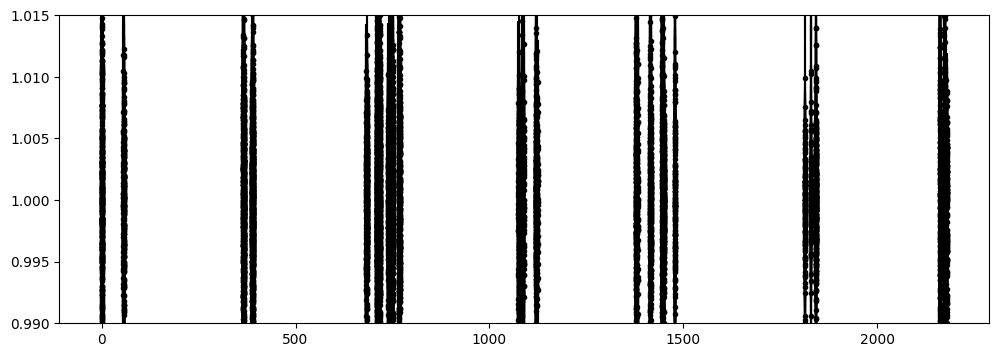

In [2]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
i = 1
file_to_use = all_files[i]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

ferr = data["diff_error"].values
good = (ferr>0)

use_pwv = 0

t = (data["bjd"].values - data["bjd"].values[0])[good]

if use_pwv and 'diff_flux_pwv' in data:
    f = data["diff_flux_pwv"].values[good]
    # used_pwv = 1
else:
    f = data['diff_flux'].values[good]

ferr = ferr[good]
fwhm = data['fwhm'].values[good]
pwv = data['PWV'].values[good]
bkg = data['sky'].values[good]
seeing = data['seeing'].values[good]
ramove = data['RA_move'].values[good]
decmove = data['DEC_move'].values[good]
exp = data['exposure'].values[good]
alc = data['ALC'].values[good]

# f = np.ones_like(t)
# sigma = 5e-3
# ferr = np.ones_like(t) * sigma
# f = f + np.random.normal(0, sigma, size=t.size)

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]
name = star_info['TARGET'].values[0]
print(name)

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,yerr=ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
np.shape(t), np.shape(f), np.shape(ferr)

((11009,), (11009,), (11009,))

In [4]:
targ = LightCurve(name = name,
                  # time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  timelike={'time': t, 'fwhm':fwhm, 'pwv':pwv, 'seeing':seeing, 'ra_move':ramove,
                           'dec_move':decmove, 'bkg':bkg, 'exposure':exp, 'artificial_lightcurve':alc,},
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



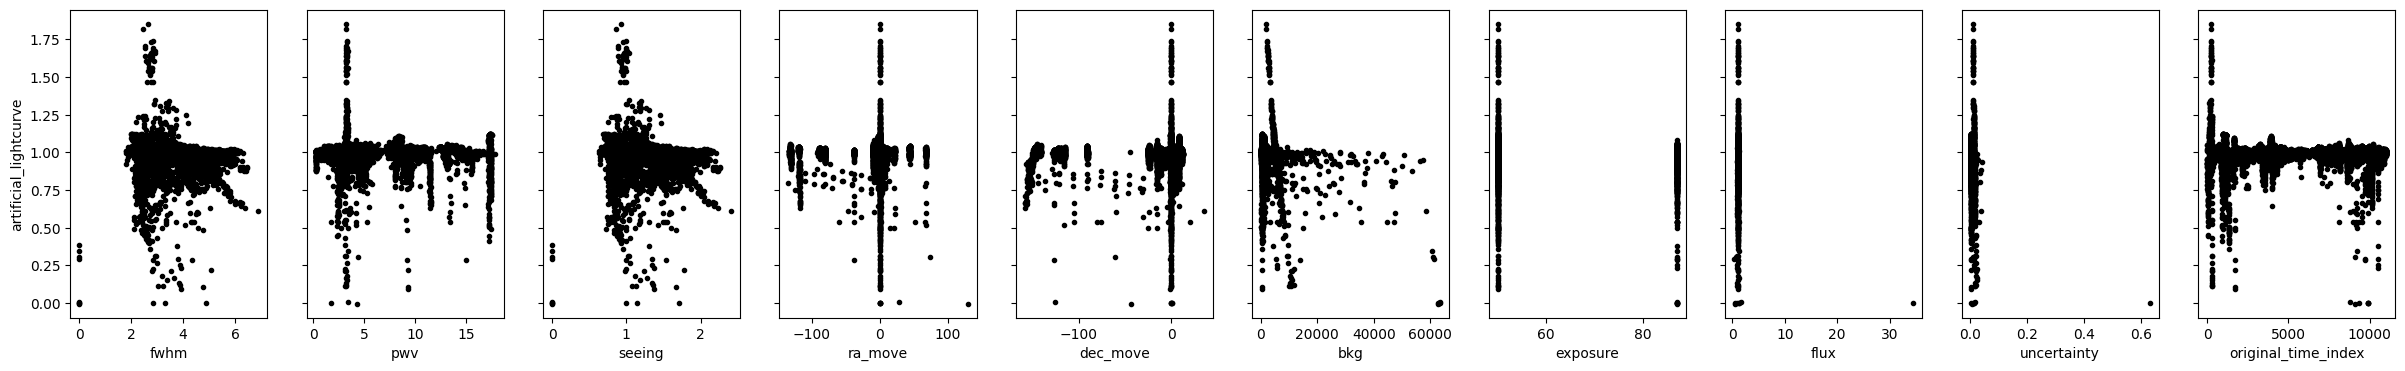

In [5]:
targ.plot_timelike_quantities('artificial_lightcurve')

Masking NaN fluxes...
Masking zero fluxes...
Masking bad weather...

            8.67% of data is flagged as bad weather ⛅.
            
Masking fwhm<1.5...

            0.07% of data is flagged as < the threshold for fwhm of 1.5.
            
Masking dust-crossing events...
Masking cosmic ray hits...

            0.24% of data is flagged as cosmics ⚡.
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.96, 1.04)

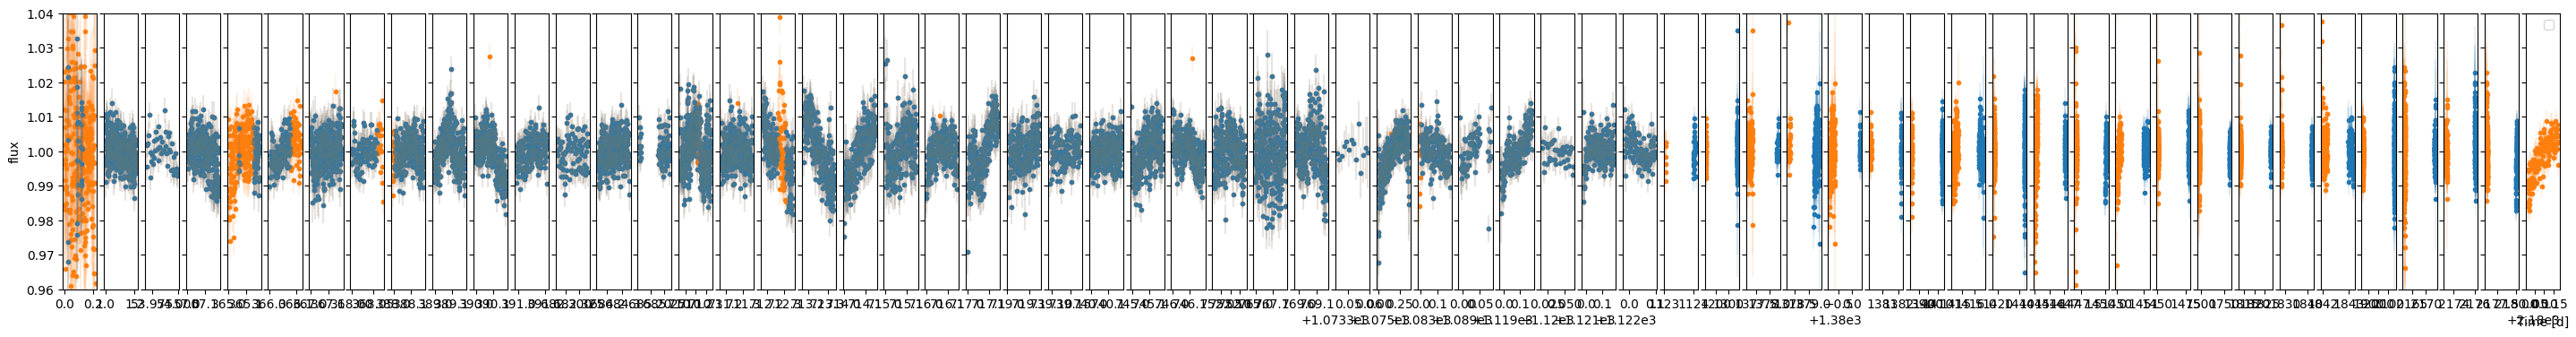

In [18]:
clean_targ = targ.clean(thresholds={'fwhm':1.5}, threshold_operators={'fwhm':"<"}, 
                        bad_weather_removal=True,
                        verbose=True)
ax = targ.plot( color='C1')
clean_targ.plot(ax=ax, color='C0', ylims=[0.96,1.04])

plt.ylim(0.96,1.04)

In [26]:
# targ_with_transit = targ.clean().inject_transit(per=10*u.d, 
#                                         epoch=0.025 * u.d, 
#                                         inc=90 * u.degree, 
#                                         rp=2 * u.R_earth, 
#                                         ld=[0.3,0.3])

In [27]:
# targ.bin(dt=20*u.minute).time

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


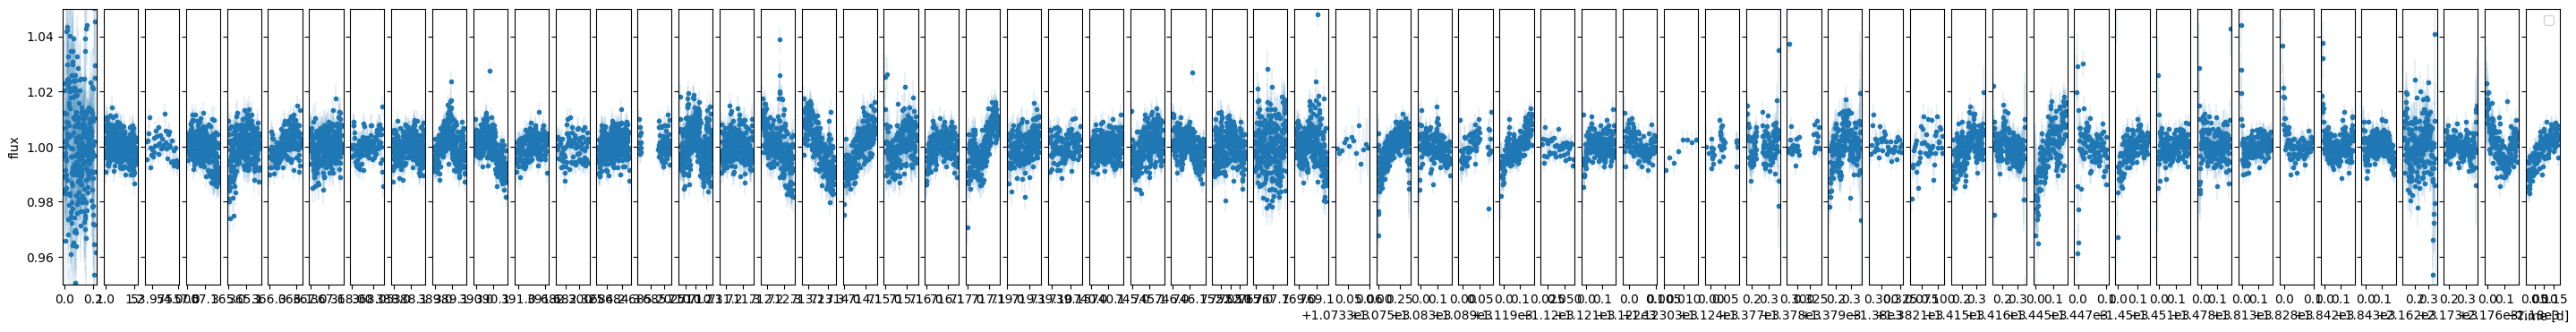

In [19]:
ax=targ.plot(ylims=[0.95,1.05])
# targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-",)

In [9]:
# a = targ.find_transits(transit_durations=[0.01,0.02,0.03,0.04],
#                             minimum_period=0.5, 
#                             maximum_period=30,
#                             oversample=10,
#                             obj="snr",
#                             minimum_n_transit=2,
#                            verbose=True, plot=True,
#                             nperiods=100000)

In [20]:
# per=2.55*u.d
# epoch=0.025 * u.d
# inc=90 * u.degree
# rp=1 * u.R_earth
# ld=[0.3,0.3]

# planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
#                                                           minimum_planet_radius=rp, 
#                                                           maximum_planet_radius=rp,
#                                                           minimum_period=per, 
#                                                           maximum_period=per,
#                                                         )
# planets

In [21]:
# lcs_with_transits, planets = targ.inject_lots_of_transits(nfake=10,
#                                                                   minimum_planet_radius=rp,
#                                                                   maximum_planet_radius=rp,
#                                                                   minimum_period=per,
#                                                                   maximum_period=10*u.d,
#                                                                   ld=ld,
#                                                           )

In [22]:
# lcs_with_transits

Deleting BLS file...
1/5...
Planet was not observed, skipping...
2/5...
Time to clean LC: 1.8960208892822266
No flares found.
Time to remove flares: 0.13231992721557617


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


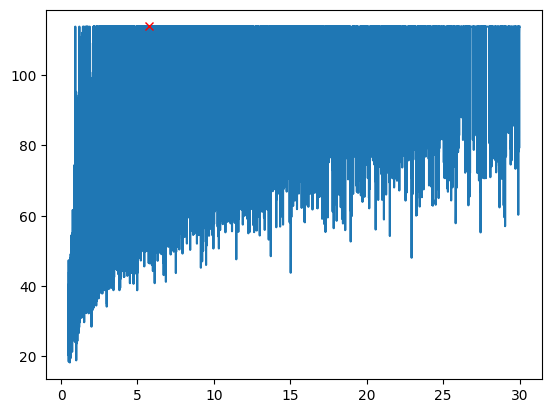

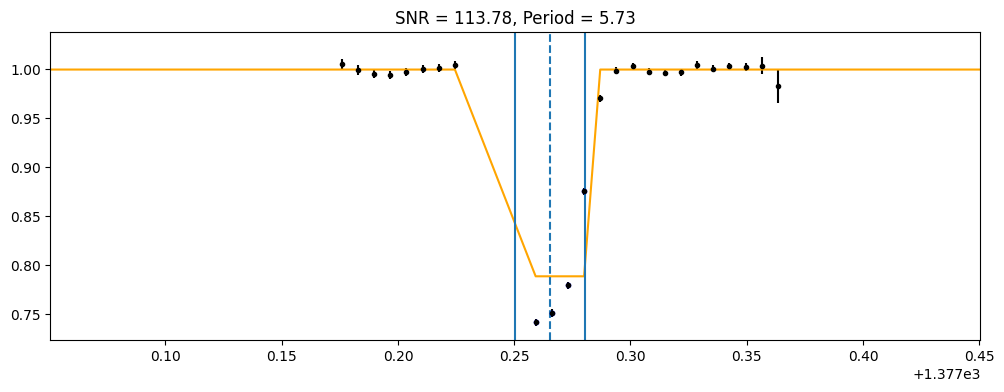

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


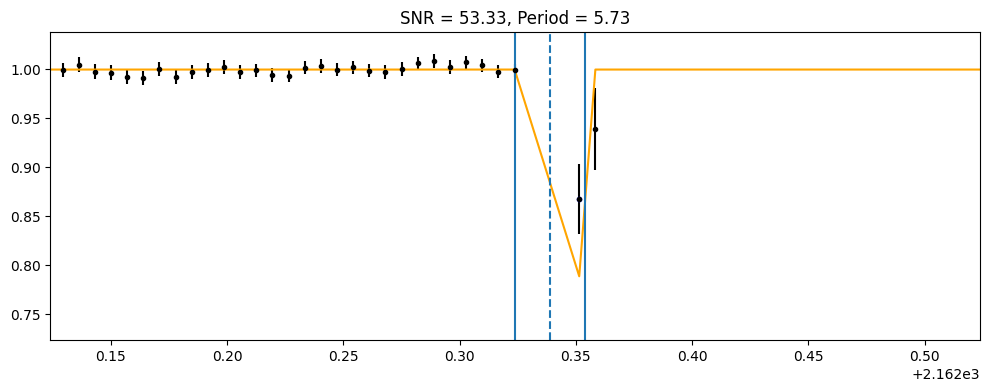

Time to BLS before detrending: 15.349755764007568


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Time to detrend: 191.9191291332245


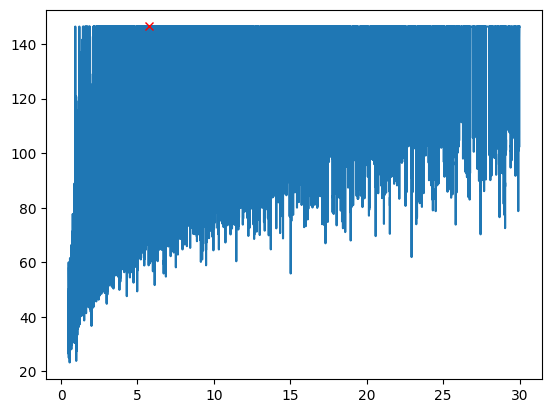

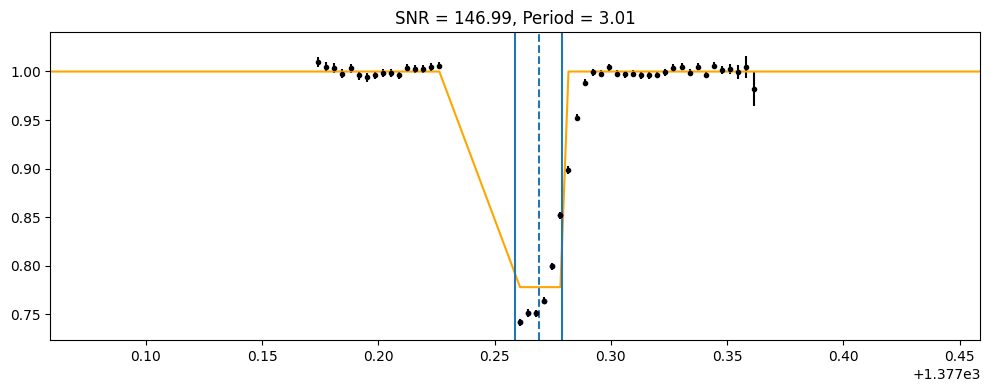

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


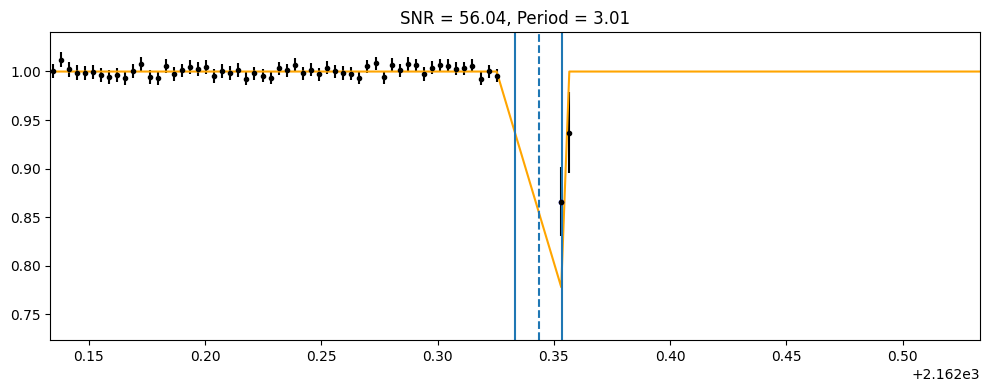

Time to BLS search: 14.769944190979004
3/5...
Planet was not observed, skipping...
4/5...
Planet was not observed, skipping...
5/5...
Planet was not observed, skipping...
Time to inject-recover 5 planets: 224.396625995636
Planets recovered: 20.0%
But did all of those planets transited during the observation window?...
Observed Planets recovered: 100.0%


In [5]:
bls_bin = (5 * u.minute)

x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=5,
                             minimum_planet_radius=0.5 * u.R_earth, 
                             maximum_planet_radius=6 * u.R_earth,
                             minimum_period=0.5 * u.d, 
                             maximum_period=20 * u.d, 
                             ld=[0.65,0.28],  # use trappist-1 (Gillon+16)
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': True,'cosmics_removal': True,
                                         'threshold_removal':True, 'thresholds':{'fwhm':1.5}, 'threshold_operators':{'fwhm':"<"}, 
                                         'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':False}, # bad_weather_boxsize, bad_weather_threshvalue
                             flare_kw = {'plot':False, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': False, 'verbose':False,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":0.5, "maximum_period":30, 'minimum_n_transit':1, 'obj':'snr',
                                      'minpower':3,'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 
                                      'plot':True, 'verbose': False, 'nperiods':100000, 'oversample':10,}, 
                            bls_bin=bls_bin,
                            recovery_kw = {'condition_on_epoch':0.5 * u.hour, 
                                           'min_n_transits': 1, 
                                           # 'meet_condition': 'any',
                                          'verbose':False},                           
                            verbose=False, plot=False, time_this_process=True,
                           plot_dir='../../Results/', save_plots=False, save_lcs=False,
                           # plot_kw={'ylims':[0.98,1.02]},
                           svname=f"../../Results/{name}_injected_planets.csv",
                           min_save=True)

In [6]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [7]:
# for k,v in targ.timelike.items():
#     if not isinstance(v, Time):
#         print(k, np.nanmedian(v))
#     else:
#         print(k, "TIME", Time(np.nanmedian(v.jd), format="jd", scale=v.scale))

In [8]:
# targ.name

In [7]:
# lcs_bls[1][0].metadata['BLS_transits_params']

In [9]:
# import pickle as pkl
# pkl.dump(lcs_bls[1][0].metadata['BLS_transits_params'], open(f"../../Results/{name}_BLS.pkl", 'wb'))

In [10]:
x = pkl.load(open(f"../../Results/{targ.name}_BLS.pkl", 'rb'))
# x

In [11]:
# x[0]
x

{1: {'period': [<Quantity 3.00794828 d>, <Quantity 3.00794828 d>],
  'power': [146.45026332900915, 146.45026332900915],
  'depth': [0.22178461538589234, 0.22178461538589234],
  'duration': [<Quantity 0.02 d>, <Quantity 0.02 d>],
  'epoch': [<Quantity 1377.26897814 d>, <Quantity 2162.34347886 d>],
  'epoch_start': [<Quantity 1377.25897814 d>, <Quantity 2162.33347886 d>],
  'epoch_end': [<Quantity 1377.27897814 d>, <Quantity 2162.35347886 d>],
  'snr': [146.98935194999254, 56.03834484437281],
  'n': [6, 1],
  'dt': [0.02083333333303017, 0.0034722222221716947],
  'frac_rec_dur': [<Quantity 1.04166667 1 / d>, <Quantity 0.17361111 1 / d>],
  'med_time_bin_start': [<Time object: scale='utc' format='jd' value=1377.2678942318164>,
   <Time object: scale='utc' format='jd' value=2162.3514264094506>],
  'med_time_bin_size': [<Quantity 0.00347222 d>, <Quantity 0.00347222 d>],
  'med_time': [<Time object: scale='utc' format='jd' value=1377.2696303429275>,
   <Time object: scale='utc' format='jd' va

In [90]:
(x[0]['n'] * bls_bin).to('d')

<Quantity [0.00694444, 0.01736111, 0.02083333, 0.02083333, 0.01041667,
           0.01388889, 0.02083333] d>

In [103]:
(x[0]['n'] * lcs_bls[0][0].dt).value/0.02

array([0.34722222, 0.86805556, 1.04166667, 1.04166667, 0.52083333,
       0.69444444, 1.04166667])

In [55]:
lcs[0].metadata['injected_planet']

{'period': [<Quantity 2.28968414 d>],
 'epoch': [<Quantity 1.93629861 d>],
 'inc': [<Quantity 1.57007816 rad>],
 'rp': [<Quantity 5.06619557 earthRad>],
 'a': [<Quantity 3.15005524 solRad>],
 'a_Rs': [<Quantity 31.50055242>],
 'ld': [[0.65, 0.28]],
 'depth': [<Quantity 0.21572603>],
 'duration': [<Quantity 0.0338915 d>]}

159
365.979130672121 d 366.0130221728387 d 0.01999999999998181 d
298
684.2452257395668 d 684.2791172402843 d 0.01999999999998181 d
311
714.011119522853 d 714.0450110235706 d 0.01999999999998181 d
325
746.0666974433152 d 746.1005889440328 d 0.01999999999998181 d
335
768.9635388150739 d 768.9974303157915 d 0.01999999999998181 d
602
1380.3092034410483 d 1380.3430949417661 d 0.01999999999998181 d
791
1813.059505367309 d 1813.0933968680267 d 0.01999999999998181 d


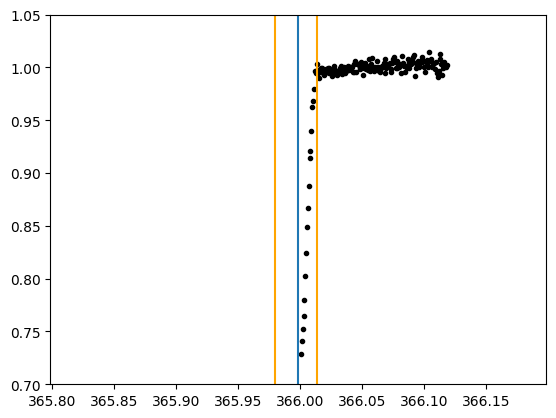

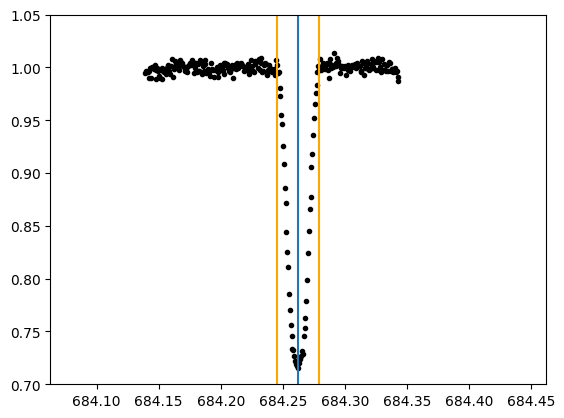

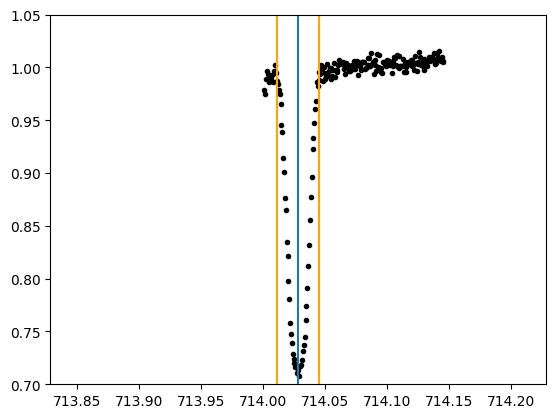

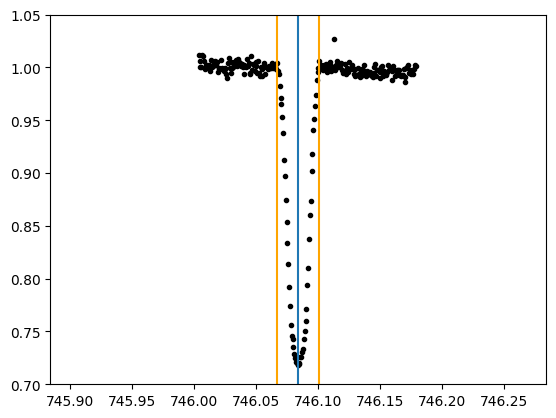

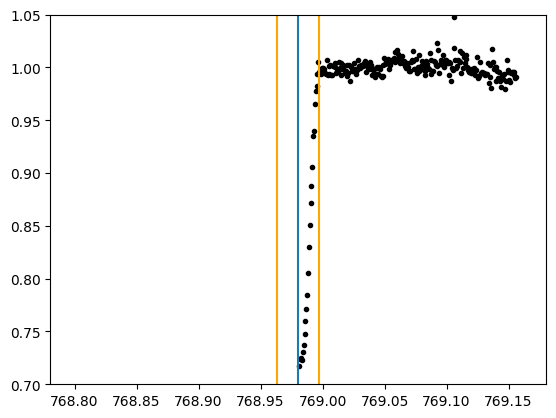

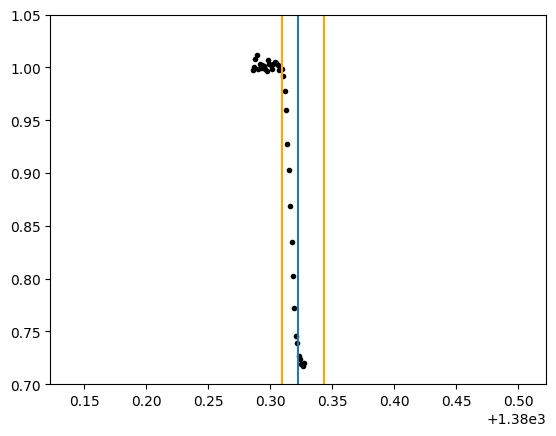

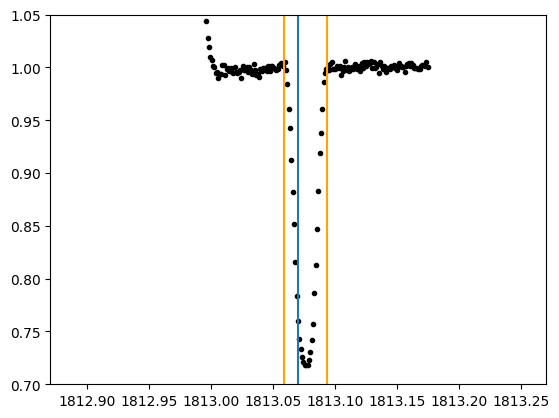

In [87]:
injected_params = lcs[0].metadata['injected_planet']
recovered_params = x[0]

planet = 0

transit_t = injected_params['epoch'][planet].to_value('d')

all_epochs = []
while transit_t < targ.time.value[-1]:
    all_epochs.append(transit_t)
    transit_t += injected_params['period'][0].to_value('d')

for transit in range(len(recovered_params['epoch'])):
    closest_transit = find_nearest(all_epochs, recovered_params['epoch'][transit].to_value('d'))
    print(closest_transit)
    inj_transit_start = all_epochs[closest_transit]*u.d - (0.5*injected_params['duration'][planet])
    inj_transit_end = all_epochs[closest_transit]*u.d + (0.5 * injected_params['duration'][planet])
    overlap = min(inj_transit_end, recovered_params['epoch_end'][transit]) - \
              max(inj_transit_start, recovered_params['epoch_start'][transit])
    print(inj_transit_start, inj_transit_end, overlap)

    plt.figure()
    plt.plot(lcs[0].time.value, lcs[0].flux, 'k.')
    plt.axvline(inj_transit_start.value, color='orange')
    plt.axvline(inj_transit_end.value, color='orange')
    plt.axvline(recovered_params['epoch'][transit].to_value('d'))
    plt.xlim(recovered_params['epoch'][transit].to_value('d')-0.2, 
             recovered_params['epoch'][transit].to_value('d')+0.2)
    plt.ylim(0.7,1.05)

In [70]:
targ.time, targ.flux

(<Time object: scale='tdb' format='jd' value=[0.00000000e+00 6.88900705e-04 1.38080074e-03 ... 2.18017329e+03
  2.18017437e+03 2.18017546e+03]>,
 array([1.02022986, 1.02308724, 1.00169802, ..., 1.00453088, 0.99593731,
        1.00270448]))

In [29]:
(targ.dt.to('s').value)

60.08255481719971

In [44]:
np.array(x[0]['n']) * (60+50)

array([220, 550, 660, 660, 330, 440, 660])

In [41]:
np.array(x[0]['n']) * (np.array(x[0]['med_exposure'])+(targ.dt.to('s').value))

array([220.16510963, 550.41277409, 660.4953289 , 660.4953289 ,
       330.24766445, 588.33021927, 882.4953289 ])

In [43]:
np.array(x[0]['med_exposure'])

array([50., 50., 50., 50., 50., 87., 87.])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Time [d]'>], dtype=object)

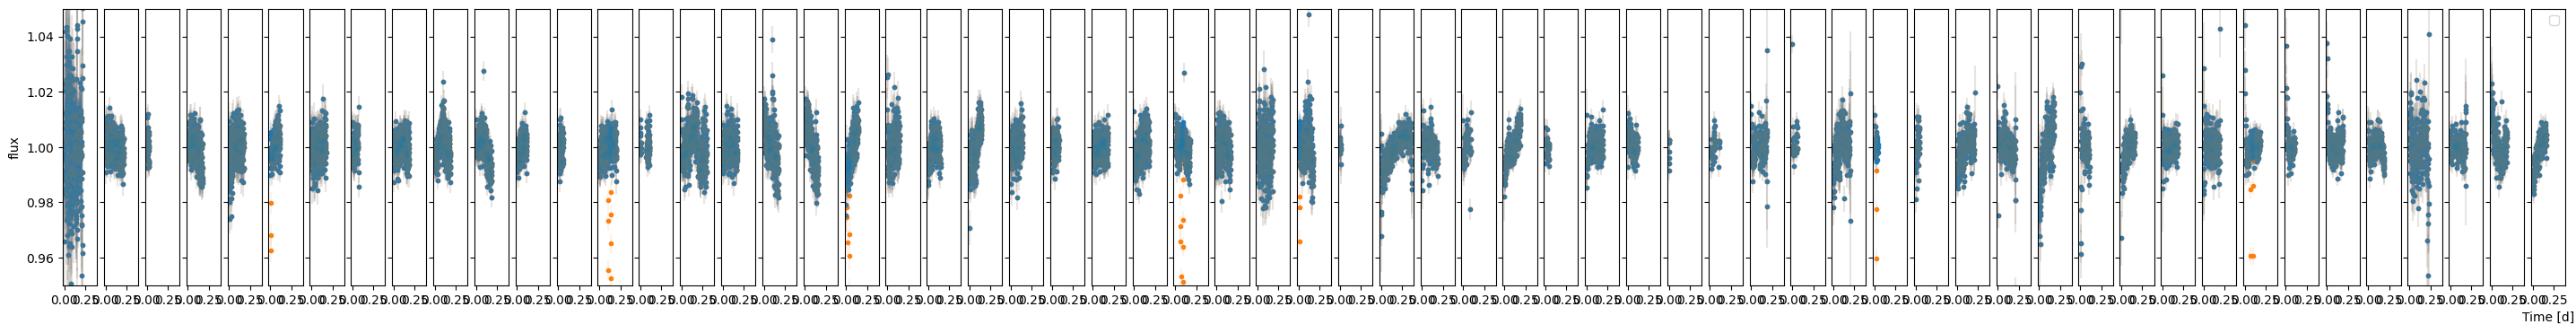

In [45]:
ax = lcs[0].plot(color="C1", ylims=[0.95, 1.05])
targ.plot(ax=ax, color="C0", ylims=[0.95, 1.05])

In [71]:
# i=4
# ax=lcs[i].plot()
# lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
# try:
#     print(lcs_bls[i][0].metadata['BLS_transits_found'])
# except:
#     print(False)
#     pass
# planets_df = pd.read_csv(f"../../Results/{targ.name}_injected_planets.csv")
# planets_df

In [72]:
# planets_df['depth'], (((planets_df['r_p'].values*u.earthRad)/(0.1*u.solRad)).decompose())**2, planets_df['rec_depth']

In [73]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0      0.14 solRad
1      0.14 solRad
2      0.14 solRad
3      0.14 solRad
4      0.14 solRad
          ...     
995    0.14 solRad
996    0.14 solRad
997    0.14 solRad
998    0.14 solRad
999    0.14 solRad
Name: r_s, Length: 1000, dtype: object

In [74]:
# period = 10**planets_df['logP']

# duration = 

# lcs_bls

Text(0.5, 0, 'Planet Radius [R_earth]')

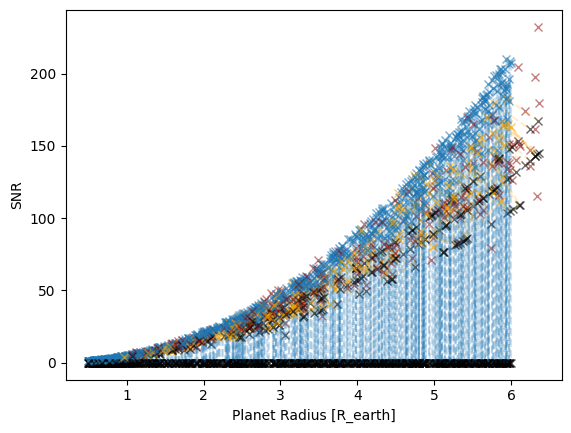

In [75]:
from astropy.units import Quantity

bls_bin = (5 * u.minute)
n_points_in_transit = planets_df['duration']/(bls_bin.to_value('day'))
lc_noise = np.nanmedian(targ.uncertainty) #1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for i,(r_p, rr_depth, dur, rec_depth, rec_dur, rec, obs, r_p_rec, snr, n) in enumerate(zip(planets_df['r_p'],
                                                            planets_df['depth'],
                                                            planets_df['duration'],
                                                          planets_df['rec_depth'],
                                                        planets_df['rec_duration'],
                                                          planets_df['recovered'],
                                                          planets_df['observed'],
                                                          rec_r_p,  planets_df['snr'], 
                                                          n_points_in_transit)):
    if i == 0:
        labeli="injected"
        labelr="recovered"
        labelnr="not recovered"
        labelo="observed"
    else:
        labeli, labelr, labelnr, labelo = None, None, None,None
        
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
        
    if r_p_rec == 0.0:
        r_p_rec = r_p
        # snr = 0 #rr_depth * dur/lc_noise

    n_rec = rec_dur/(bls_bin.to_value('day'))

    derived_snr = rr_depth * np.sqrt(n)/lc_noise #np.sqrt(n)/lc_noise
    rec_snr = rec_depth * np.sqrt(n_rec) / lc_noise
    # derived_snr_theory = rr_depth * rec_dur / lc_noise
    plt.plot([r_p], [derived_snr], 'x', color=color, alpha=0.6,label="Derived SNR")
    plt.plot([r_p_rec], [rec_snr], 'x', color='k', alpha=0.6,label="Recovered SNR")
    # plt.plot([r_p], [derived_snr2], 'x', color=color, alpha=0.6,label=labeli)
    plt.plot([r_p,r_p_rec], [derived_snr, rec_snr], '--', color=color, alpha=0.2)

    # print(f"""
    # Rp/R* depth = {rr_depth:.3f},
    # Recovered depth = {rec_depth:.3f},
    # Theoretical duration = {dur:.3f},
    # Recovered duration = {rec_dur:.3f},
    # Number of points in transit = {n:.0f},
    # lc noise = {lc_noise}
    # """)

    # if obs == 1.0:
    #     plt.plot([r_p], [derived_snr], 'o', color=color, alpha=0.6, label=labelo)
    
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5, label=labelr)
    
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")
# plt.legend()

Fraction of injections observed: 0.541


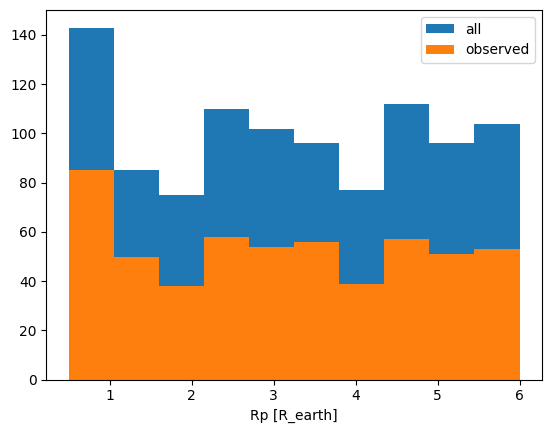

In [76]:
plt.hist(planets_df['r_p'], label='all')
plt.hist(planets_df['r_p'][planets_df['observed'] == 1.0], label='observed')
plt.xlabel("Rp [R_earth]")
plt.legend()

print(f"Fraction of injections observed: {len(planets_df['r_p'][planets_df['observed'] == 1.0])/len(planets_df['r_p'])}")

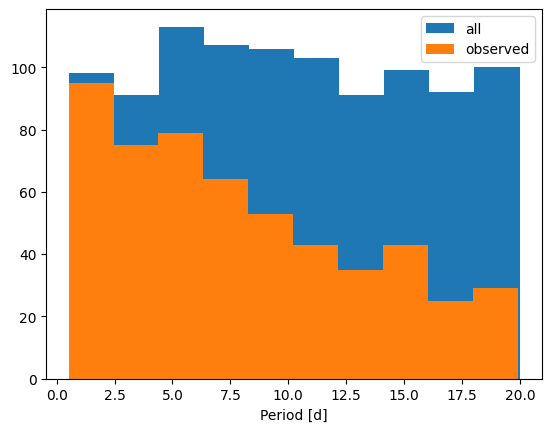

In [77]:
plt.hist(10**planets_df['logP'],label="all")
plt.hist(10**planets_df['logP'][planets_df['observed'] == 1.0], label="observed")
plt.xlabel("Period [d]")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


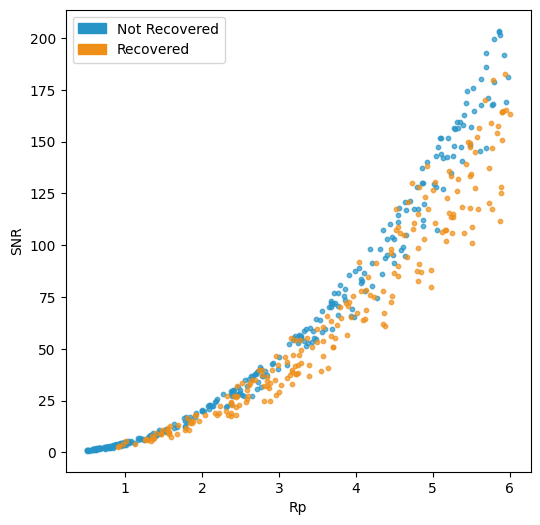

In [78]:
x = planets_df['r_p'][planets_df['observed'] == 1.0]
plot_transitparams(x=x, 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Rp", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=10,)
                   # svname=f"../../Results/{name}_injected_snr_Rp.png")

# plt.plot(sorted(x), (np.array(sorted(x))**2) * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0]) /lc_noise)

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/occultence/recovery/plots.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  error_in_frac = (1 / N) * np.sqrt(n_success * (1 + (n_success / N)))


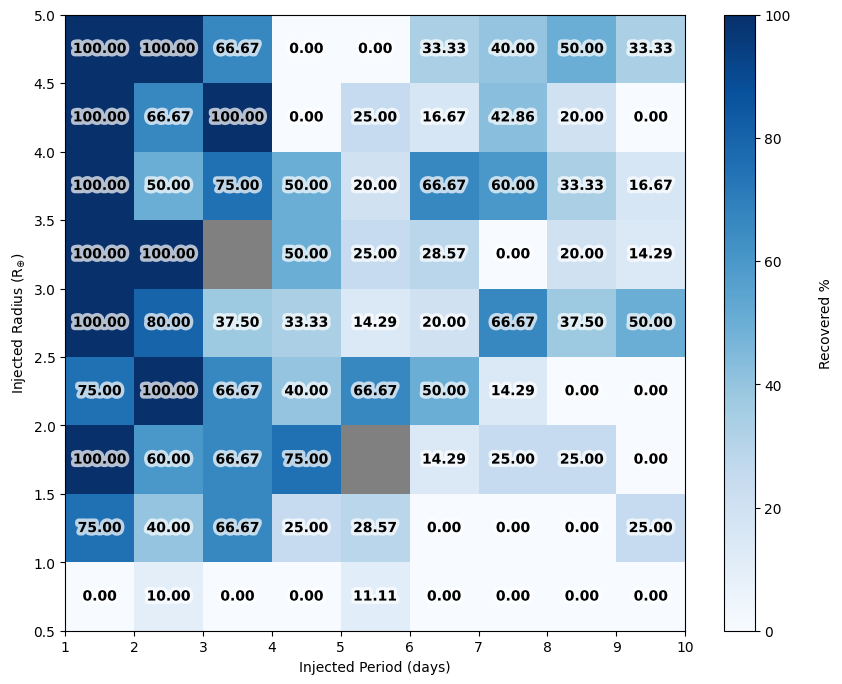

In [79]:
P_bins = np.linspace(1,10,10)
R_bins = np.linspace(0.5,5,10)

twod_plot(x=10**planets_df['logP'],
          y=planets_df['r_p'],
          z=planets_df['recovered'],
          x_bins=P_bins,
          y_bins=R_bins,
          zlabel="Recovered %",
          statistic="mean",
          addtext=True,)
          # svname=f"../../Results/{name}_recovered.png")

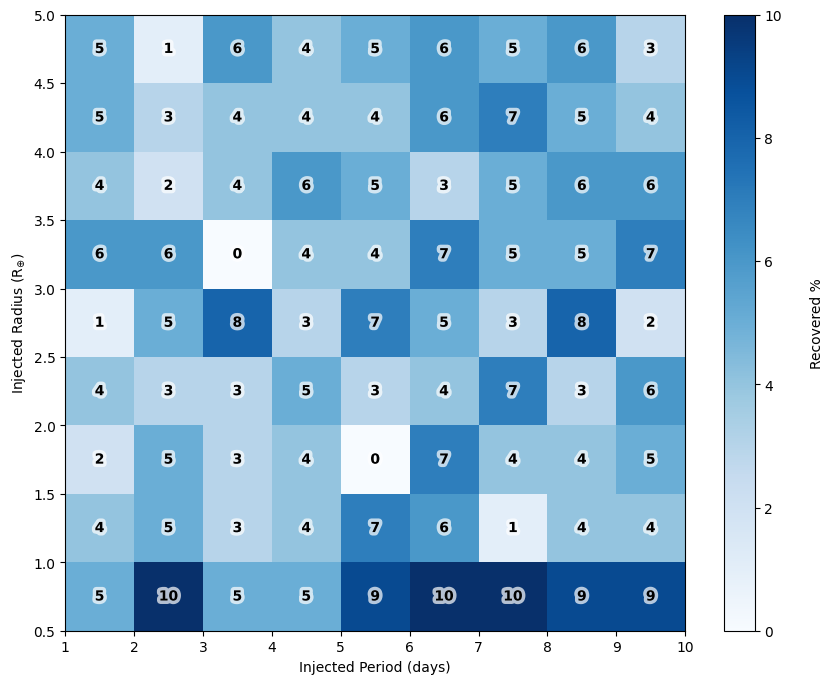

In [80]:
twod_plot(x=10**planets_df['logP'],
          y=planets_df['r_p'],
          z=planets_df['recovered'],
          x_bins=P_bins,
          y_bins=R_bins,
          zlabel="Recovered %",
          statistic="count",
          nsig="%0.0f",
          addtext=True,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


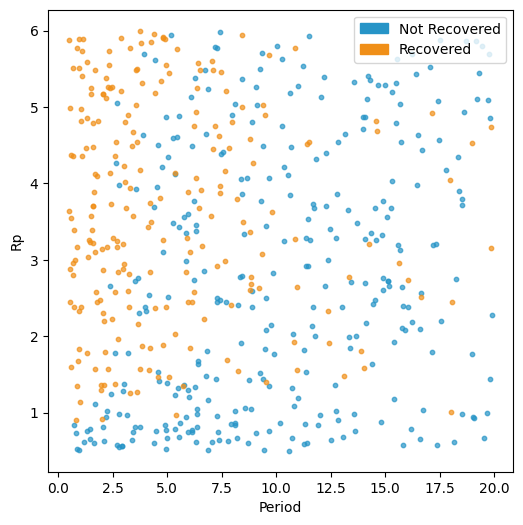

In [81]:
plot_transitparams(x=10**planets_df['logP'][planets_df['observed'] == 1.0], 
                   y=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="Rp", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=10,)